C:\Users\cliff\AppData\Local\Temp\ipykernel_36572\409007412.py:86: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([str(int(tick)) if int(tick) % 2 == 0 else "" for tick in ax.get_xticks()])


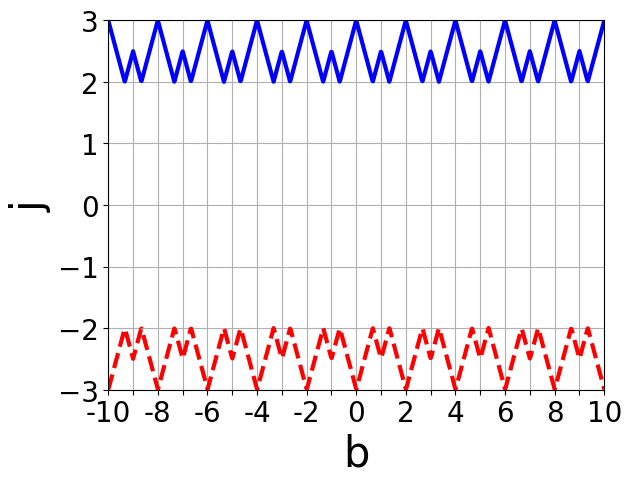

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def find_max_per_column(arr):
    arr = np.array(arr, dtype=float)  # Ensure dtype is float to handle NaNs
    
    max_values = []
    max_row_indices = []
    
    for col in range(arr.shape[1]):
        column = arr[:, col]
        if np.any(~np.isnan(column)):  # Check for non-NaN values
            column_without_nans = column[~np.isnan(column)]  # Remove NaNs
            max_value = np.max(column_without_nans)
            max_row_index = np.argmax(column == max_value)
        else:
            max_value = np.nan
            max_row_index = np.nan
        
        max_values.append(max_value)
        max_row_indices.append(max_row_index)
    
    return max_values, max_row_indices

def find_min_per_column(arr):
    arr = np.array(arr, dtype=float)  # Ensure dtype is float to handle NaNs
    
    min_values = []
    min_row_indices = []
    
    for col in range(arr.shape[1]):
        column = arr[:, col]
        if np.any(~np.isnan(column)):  # Check for non-NaN values
            column_without_nans = column[~np.isnan(column)]  # Remove NaNs
            min_value = np.min(column_without_nans)
            min_row_index = np.argmin(column == min_value)
        else:
            min_value = np.nan
            min_row_index = np.nan
        
        min_values.append(min_value)
        min_row_indices.append(min_row_index)
    
    return min_values, min_row_indices

def main():
    # Load data from CSV files
    vortex_path = r"..\..\src\csv\vorticies.csv"
    ic_max_path = r"..\..\src\csv\Ic_max.csv"
    ic_min_path = r"..\..\src\csv\Ic_min.csv"

    vortex = np.array(pd.read_csv(vortex_path).values)
    ic_max = np.array(pd.read_csv(ic_max_path).values)
    ic_min = np.array(pd.read_csv(ic_min_path).values)

    # Find maximum I_c values for each column
    max_values, indices = find_max_per_column(ic_max)

    min_values, indices = find_min_per_column(ic_min)

    v_n = []

    indices = [idx for idx in indices if idx is not np.nan]

    MagField = np.linspace(-10,10,1000)

    for i in indices:
        v_n.append(vortex[i])

    # print(v_n)

    x_locator = MultipleLocator(1)  # X-axis ticks at integer multiples
    y_locator = MultipleLocator(1)  # Y-axis ticks at integer multiples
    ax = plt.gca()
    ax.xaxis.set_major_locator(x_locator)
    ax.yaxis.set_major_locator(y_locator)
    plt.plot(MagField, max_values, color='blue', linewidth=3)
    plt.plot(MagField, np.array(min_values), linestyle='--', color='red', linewidth=3)
    plt.xlim(-10,10)
    plt.ylim(-3,3)
    plt.grid()  
    plt.tick_params(axis='both', which='major', labelsize=20)  # For major ticks
    plt.tick_params(axis='both', which='minor', labelsize=12)
    ax.set_xticklabels([str(int(tick)) if int(tick) % 2 == 0 else "" for tick in ax.get_xticks()])
    # ax.set_yticklabels([str(int(tick)) if int(tick) % 2 == 0 else "" for tick in ax.get_yticks()])
    plt.xlabel("b", fontsize=30)
    plt.ylabel("j", fontsize=30)
    plt.show()
    plt.close()

if __name__ == "__main__":
    main()